# AB TEST

## Эксперимент проходил с 2024-11-22 по 2024-11-28 включительно. Для эксперимента были задействованы 2 и 1 группы. 
## В группе 2 был использован один из новых алгоритмов рекомендации постов, группа 1 использовалась в качестве контроля

In [35]:
import pandas as pd
import pandahouse

# подключение к базе данных
connection = {'host': 'https://clickhouse.lab.karpov.courses',
'database':'simulator_20241220',
'user':'student',
'password':'dpo_python_2020'
}


# запрос к бд
q = """
SELECT exp_group,
user_id,
sum(action = 'like') as likes,
sum(action = 'view') as views,
likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2024-11-22' and '2024-11-28'
and exp_group in (2,1)
GROUP BY exp_group, user_id
"""

In [36]:
df = pandahouse.read_clickhouse(q, connection=connection)
df 

,exp_group,user_id,likes,views,ctr
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750
...,...,...,...,...,...
19892,1,132567,52,326,0.159509
19893,1,30872,11,59,0.186441
19894,2,25383,42,127,0.330709
19895,2,139020,17,41,0.414634


In [37]:
df.groupby('exp_group').count() # смотрим размер каждой группы

,user_id,likes,views,ctr
exp_group,,,,
1,10020,10020,10020,10020
2,9877,9877,9877,9877


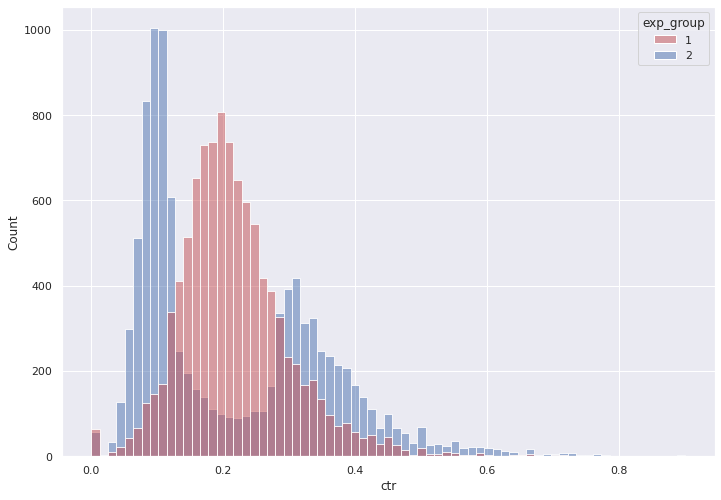

In [17]:
# Построим графики ctr двух исследуемых групп
import seaborn as sns
sns.set(rc={'figure.figsize':(11.7,8.27)})
groups = sns.histplot(data = df,
                      x='ctr',
                      hue='exp_group',
                      palette = ['r', 'b'],
                      alpha=0.5,
                      kde=False)

По графику видно, что ctr 2 группы, в которой тестировался новый алгоритм, имеет двумодальное распределение

## T-test

In [18]:
#T-тест
import matplotlib.pyplot as plt
from scipy import stats
stats.ttest_ind(df[df.exp_group == 1].ctr,
                df[df.exp_group == 2].ctr,
                equal_var=False)

Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)

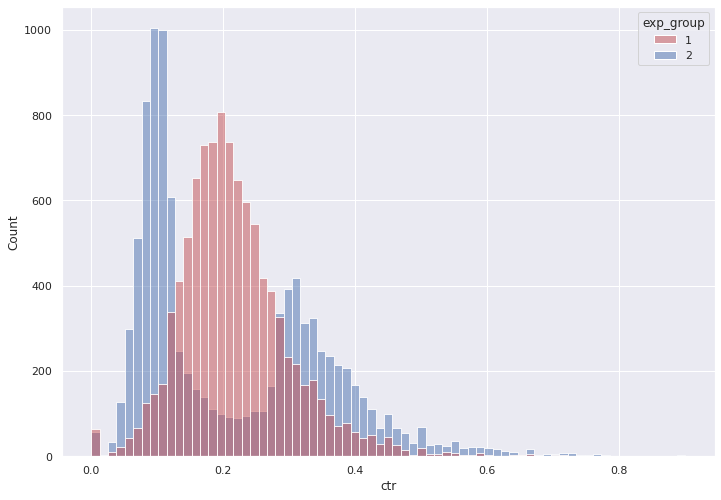

In [19]:
groups = sns.histplot(data = df, 
              x='ctr', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

pvalue > 0.05 => т-тест говорит о том, что нет статистического различия между средними распределений в этих группах. 
полагаю, что это связано с тем, что т-тест предполагает нормальное распределение и чувствителен к выбросам и аномалиям в данных
в группе 2, где тестировался новый алгоритм, распределение ctr является двухмодальным. скошенность и выбросы сильно влияют на т-тест, поэтому в этом случае он может дать некорректный результат

## Mann–Whitney-test

In [20]:
stats.mannwhitneyu(df[df.exp_group == 1].ctr, 
                   df[df.exp_group == 2].ctr,
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)

pvalue значительно меньше 0.05, что говорит о том, что статистические различия есть. 
тест Манна-Уитни не нуждается в нормальном распределении данных. в случае двухмодального распределения следует полагаться на результаты теста Манна-Уитни больше, чем на т-тест

## Непараметрический бутстреп

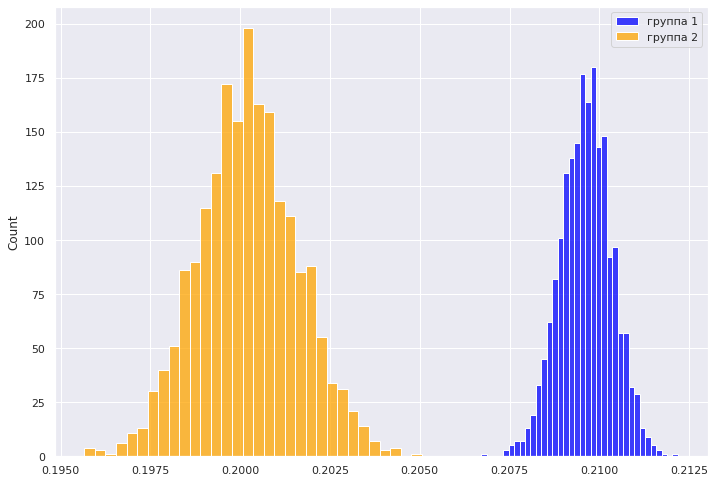

In [41]:
import numpy as np
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):

    poisson_bootstraps1 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes1))).astype(np.int64)

    poisson_bootstraps2 = stats.poisson(1).rvs(
            (n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)

    return globalCTR1, globalCTR2


df = pandahouse.read_clickhouse(q, connection=connection)

likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()

ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)

sns.histplot(ctr1, label='группа 1', color='blue')
sns.histplot(ctr2, label='группа 2', color='orange')
plt.legend()

<Axes: ylabel='Count'>

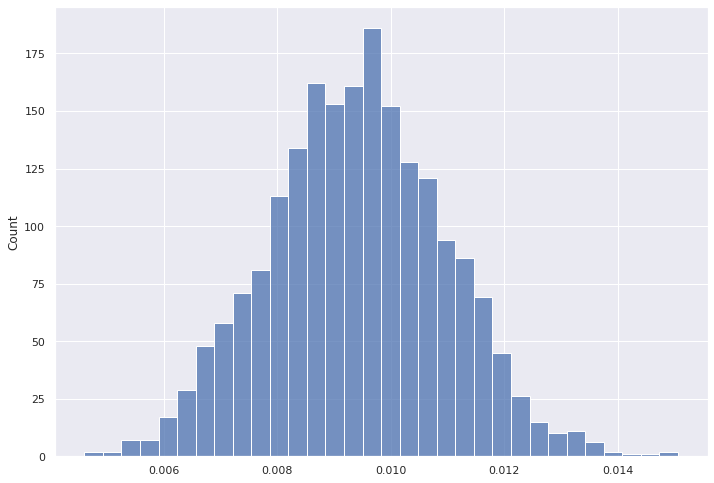

In [44]:
#Разница между глобальными CTR

sns.histplot(ctr1 - ctr2)

Бутстреп показывает, что CTR первой группы, в которой остаётся старый алгоритм, больше второй, где введён новый алгоритм.
Это может говорить, что новый алгоритм справляется хуже предыдущего

## Банкетное преобразование

In [73]:
q = """

SELECT exp_group, bucket,
    sum(likes)/sum(views) as bucket_ctr,
    quantileExact(0.9)(ctr) as ctr9
FROM (SELECT exp_group, 
        xxHash64(user_id)%50 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM {db}.feed_actions 
    WHERE toDate(time) between '2024-11-22' and '2024-11-28'
        and exp_group in (1,2)
    GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""

df = pandahouse.read_clickhouse(q, connection=connection)

#тест Манна-Уитни видит отличие
stats.mannwhitneyu(df[df.exp_group == 1].bucket_ctr, 
                   df[df.exp_group == 2].bucket_ctr, 
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)

In [74]:
stats.ttest_ind(df[df.exp_group == 1].bucket_ctr, 
                   df[df.exp_group == 2].bucket_ctr, 
                   equal_var = False)

Ttest_indResult(statistic=5.614819358149381, pvalue=4.592644937473873e-07)

В результате банкетного преобразования тест Манна Уитни и Т-тест показывают, что есть различие в группах

<Axes: xlabel='bucket_ctr', ylabel='Count'>

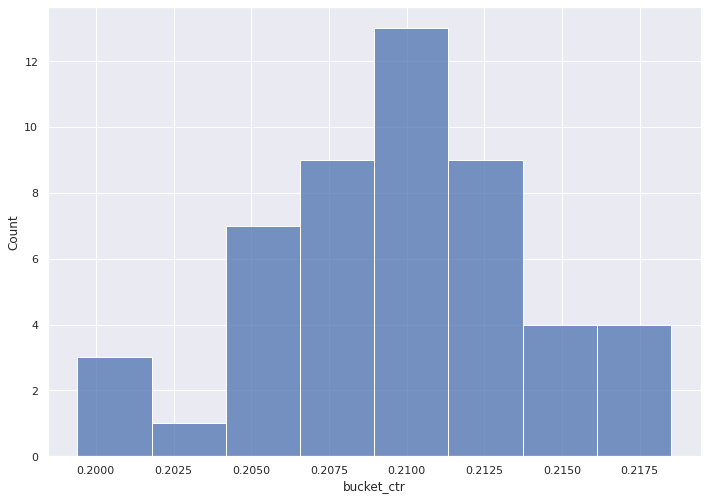

In [46]:
sns.histplot(df[df.exp_group == 1].bucket_ctr)

<Axes: xlabel='bucket_ctr', ylabel='Count'>

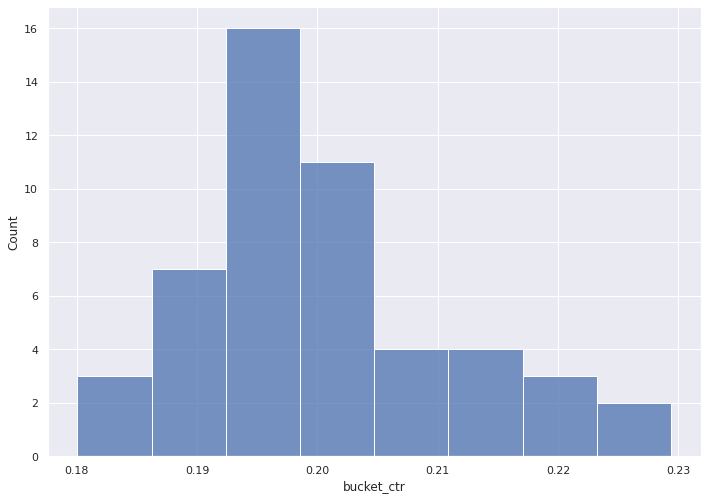

In [75]:
sns.histplot(df[df.exp_group == 2].bucket_ctr) 

Видно, что банкетное преобразование сильно сгласило ctr в группе 2, из-за чего распределение стало одномодальным и походить на нормальное также стало больше в сравнении с тем, что было до преобразования

## Дополнительные визуализации

Для лучшего понимания добавим пару визуализаций

In [82]:
q = """
SELECT exp_group,
user_id,
sum(action = 'like') as likes,
sum(action = 'view') as views,
likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2024-11-22' and '2024-11-28'
and exp_group in (2,1)
GROUP BY exp_group, user_id
"""

df = pandahouse.read_clickhouse(q, connection=connection)

<Axes: ylabel='ctr'>

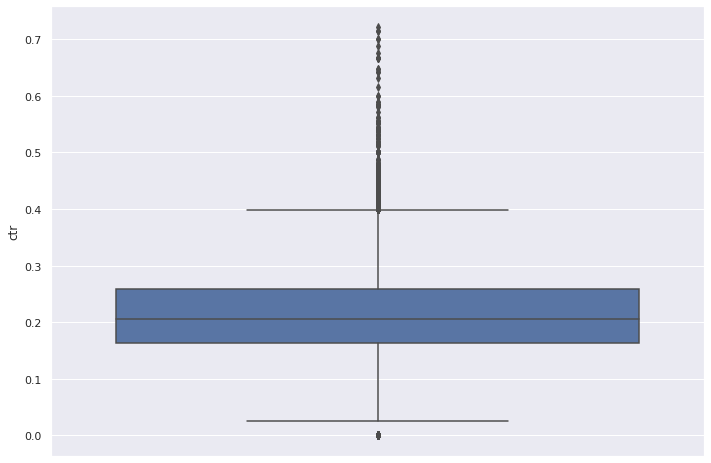

In [84]:
sns.boxplot(y=df[df.exp_group == 1]["ctr"])

<Axes: ylabel='ctr'>

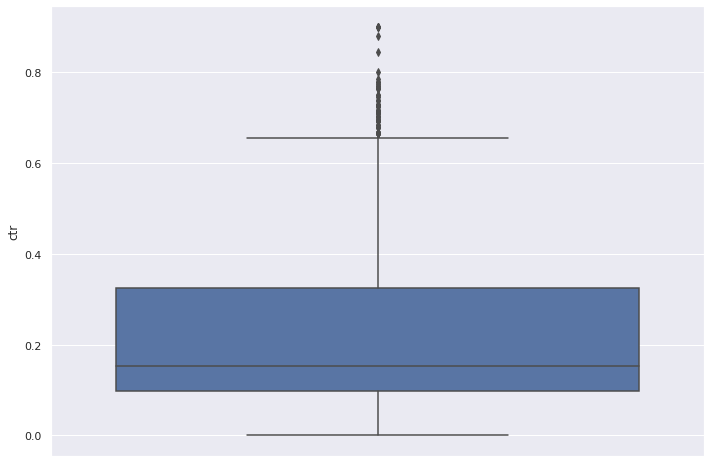

In [85]:
sns.boxplot(y=df[df.exp_group == 2]["ctr"])

<Axes: xlabel='exp_group', ylabel='ctr'>

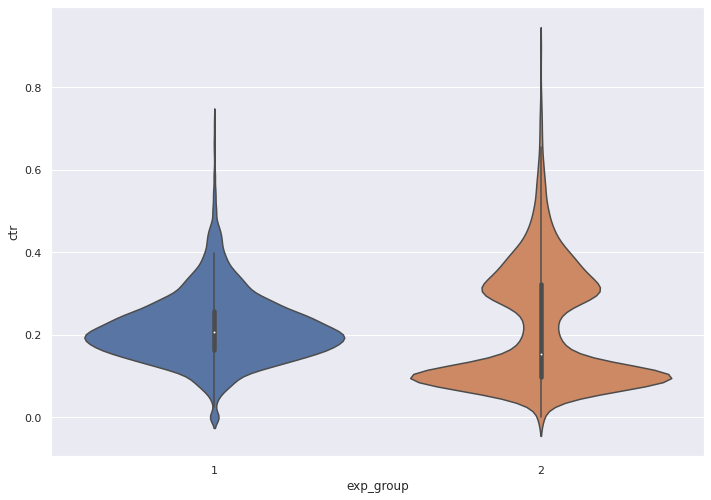

In [86]:
sns.violinplot(data=df,  y="ctr", x="exp_group")

По графикам boxplot (ящик с усами) и violin plot (виолончельный график) видно, что в группе 2 выросло количество пользователей, для которых ctr стал ниже, но в то же время также выросло число тех, для кого этот показатель стал выше. Медиана группы 2 меньше медианы первой группы, но верхняя граница 2 группы выше первой. 

Видно, что в предыдущем алгоритме больше пользователей со средними показателями ctr, а новый алгоритм, наоборот, разбивает пользователей на тех, кто доволен больше и меньше. Количество пользователей со средним ctr при этом значительно ниже

Думаю, что в данном случае следует попробовать проанализировать данные на более длинном промежутке времени, если есть такая возможность, а также проверить отток аудитории. Если "счастливых" (с высоким ctr) пользователей стало больше, как и "несчастливых", то как ведут себя те, у кого ctr стал ниже? Вполне вероятно, что при введении этого алгоритма аудитория может сократиться в таком случае.

На основе результатов тестов и полученных статистических данных считаю, что новый алгоритм справляется неплохо, но требует доработки, поэтому распространять его на всех пользователей приложения преждевременно.